# OCTA Classifier — Train Best Model


In [1]:
import sys
import logging
from pathlib import Path
import torch
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

PROJECT_ROOT = Path().resolve()                    
sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT       = PROJECT_ROOT.parent / "data"     
EXCEL_PATH      = DATA_ROOT / "master_excels" / "master_table.xlsx"
ENCODER_PATH    = PROJECT_ROOT.parent / "encoders" / "results" / "phase2" / "grl" / "pretrained" / "final_encoder.pth"
RESULTS         = PROJECT_ROOT / "results"
BEST_MODEL_DIR  = RESULTS / "best_model"
BEST_MODEL_PATH = BEST_MODEL_DIR / "best_model.pth"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(message)s"
)

print(f"Device      : {device}")
print(f"Project     : {PROJECT_ROOT}")
print(f"Data root   : {DATA_ROOT}")
print(f"Excel       : {EXCEL_PATH}")
print(f"Encoder     : {ENCODER_PATH}")
print(f"Best model  : {BEST_MODEL_PATH}")

Device      : cuda
Project     : C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier
Data root   : C:\Users\klara\Desktop\Fianl\03_Model_Training\data
Excel       : C:\Users\klara\Desktop\Fianl\03_Model_Training\data\master_excels\master_table.xlsx
Encoder     : C:\Users\klara\Desktop\Fianl\03_Model_Training\encoders\results\phase2\grl\pretrained\final_encoder.pth
Best model  : C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model\best_model.pth


In [2]:
from scripts.training import TrainConfig

#   Finálny config (run_151) 

BEST_CFG = TrainConfig(
    encoder_path    = str(ENCODER_PATH),
    experiment_name = "full",

    fusion_type     = "transformer",
    encoder_mode    = "mean_patch",
    hidden_dims     = [512],
    dropout         = 0.4,
    use_bn          = True,
    num_classes     = 4,

    unfreeze_last_n_blocks = 4,
    encoder_lr_multiplier  = 0.05,

    lr              = 1e-4,
    label_smoothing = 0.0,
    modality_dropout_prob = 0.0,

    epochs          = 60,
    batch_size      = 32,
    weight_decay    = 1e-4,
    warmup_epochs   = 10,
    min_lr          = 1e-6,
    grad_clip       = 1.0,
    use_amp         = True,
    class_weights   = "auto",

    tf_num_heads    = 4,
    tf_num_layers   = 1,
    tf_dropout      = 0.1,

    num_workers     = 4,
    seed            = 42,
)

In [3]:
from scripts.training import train_one_run, save_best_model, load_best_model

if BEST_MODEL_PATH.exists():
    print(f"Model už existuje → načítavam z {BEST_MODEL_DIR}")
    model, loaded_cfg = load_best_model(
        BEST_MODEL_DIR,
        device,
        encoder_path_override=ENCODER_PATH,
    )
    metrics_path = BEST_MODEL_DIR / "metrics.csv"
    history = pd.read_csv(metrics_path).to_dict("records") if metrics_path.exists() else []
    print("Model načítaný.")
else:
    print("Model neexistuje → trénujem...")
    BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)

    results = train_one_run(
        cfg        = BEST_CFG,
        excel_path = EXCEL_PATH,
        data_root  = DATA_ROOT,
        run_dir    = BEST_MODEL_DIR,
        device     = device,
    )

    tmp_model = BEST_MODEL_DIR / "model.pth"
    if tmp_model.exists():
        tmp_model.rename(BEST_MODEL_PATH)

    history = results["history"]
    model, loaded_cfg = load_best_model(
        BEST_MODEL_DIR,
        device,
        encoder_path_override=ENCODER_PATH,
    )
    print(f"Tréning hotový. Model uložený → {BEST_MODEL_PATH}")

2026-05-14 11:10:11,496 [INFO] Encoder načítaný (všetko zmrazené): C:\Users\klara\Desktop\Fianl\03_Model_Training\encoders\results\phase2\grl\pretrained\final_encoder.pth


Model už existuje → načítavam z C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model


2026-05-14 11:10:11,657 [INFO] Encoder: fully frozen
2026-05-14 11:10:11,669 [INFO] OctaClassifier | fusion=transformer | encoder_mode=mean_patch | fused_dim=384 | hidden_dims=[512]
2026-05-14 11:10:11,775 [INFO] Best model načítaný z C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model


Model načítaný.


2026-05-14 11:10:11,987 [INFO] Training curves uložené → C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model\training_curves.png


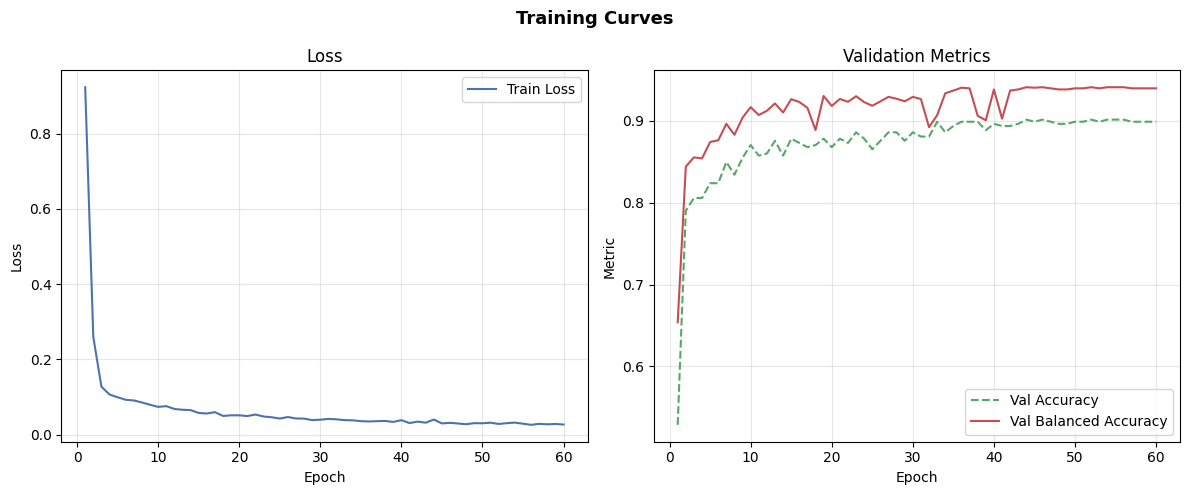

In [4]:
from scripts.training import plot_training_curves


metrics_path = BEST_MODEL_DIR / "metrics.csv"
curves_path  = BEST_MODEL_DIR / "training_curves.png"

if history:
    plot_training_curves(
        history  = history,
        save_dir = BEST_MODEL_DIR,
        show     = True,
    )
elif metrics_path.exists():
    history_df = pd.read_csv(metrics_path)
    history = history_df.to_dict("records")
    plot_training_curves(
        history  = history,
        save_dir = BEST_MODEL_DIR,
        show     = True,
    )
elif curves_path.exists():
    img = Image.open(curves_path)
    plt.figure(figsize=(12, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("História nie je dostupná — preskakujem training curves.")

In [5]:
from scripts.dataset import load_dataframes, build_dataloaders, LABEL_NAMES
from scripts.evaluation import evaluate, print_metrics, plot_confusion_matrices

_, val_df, test_df = load_dataframes(EXCEL_PATH, BEST_CFG.experiment_name)

import pandas as pd
_, val_loader, test_loader = build_dataloaders(
    train_df  = pd.DataFrame(),
    val_df    = val_df,
    test_df   = test_df,
    data_root = DATA_ROOT,
    batch_size = 64,
    num_workers = 4,
)

val_res  = evaluate(model, val_loader,  LABEL_NAMES, device)
test_res = evaluate(model, test_loader, LABEL_NAMES, device)

print_metrics(val_res,  LABEL_NAMES, split_name="Validation")
print_metrics(test_res, LABEL_NAMES, split_name="Test")

2026-05-14 11:10:12,745 [INFO] Experiment 'full' | use_col=use_for_cls_full | split_col=split_full | train=1759 | val=386 | test=358
2026-05-14 11:10:12,747 [INFO] OctaClsDataset: 0 samples (skipped=0, is_train=True)
2026-05-14 11:10:12,757 [INFO] OctaClsDataset: 386 samples (skipped=0, is_train=False)
2026-05-14 11:10:12,767 [INFO] OctaClsDataset: 358 samples (skipped=0, is_train=False)



Validation Metrics
Balanced Accuracy : 0.9412
Macro F1          : 0.8753
Accuracy          : 0.9016

Per-class Recall:
  recall_AMD          : 1.0000
  recall_DR           : 0.8415
  recall_Healthy      : 0.9231
  recall_RVO          : 1.0000

Classification Report:
              precision    recall  f1-score   support

         AMD       0.64      1.00      0.78         7
          DR       0.99      0.84      0.91       183
     Healthy       0.83      0.92      0.87       117
         RVO       0.89      1.00      0.94        79

    accuracy                           0.90       386
   macro avg       0.84      0.94      0.88       386
weighted avg       0.91      0.90      0.90       386


Test Metrics
Balanced Accuracy : 0.8588
Macro F1          : 0.8228
Accuracy          : 0.8743

Per-class Recall:
  recall_AMD          : 0.8571
  recall_DR           : 0.9126
  recall_Healthy      : 0.8427
  recall_RVO          : 0.8228

Classification Report:
              precision    recall  

2026-05-14 11:10:53,038 [INFO] Confusion matrices uložené → C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model\confusion_matrices.png


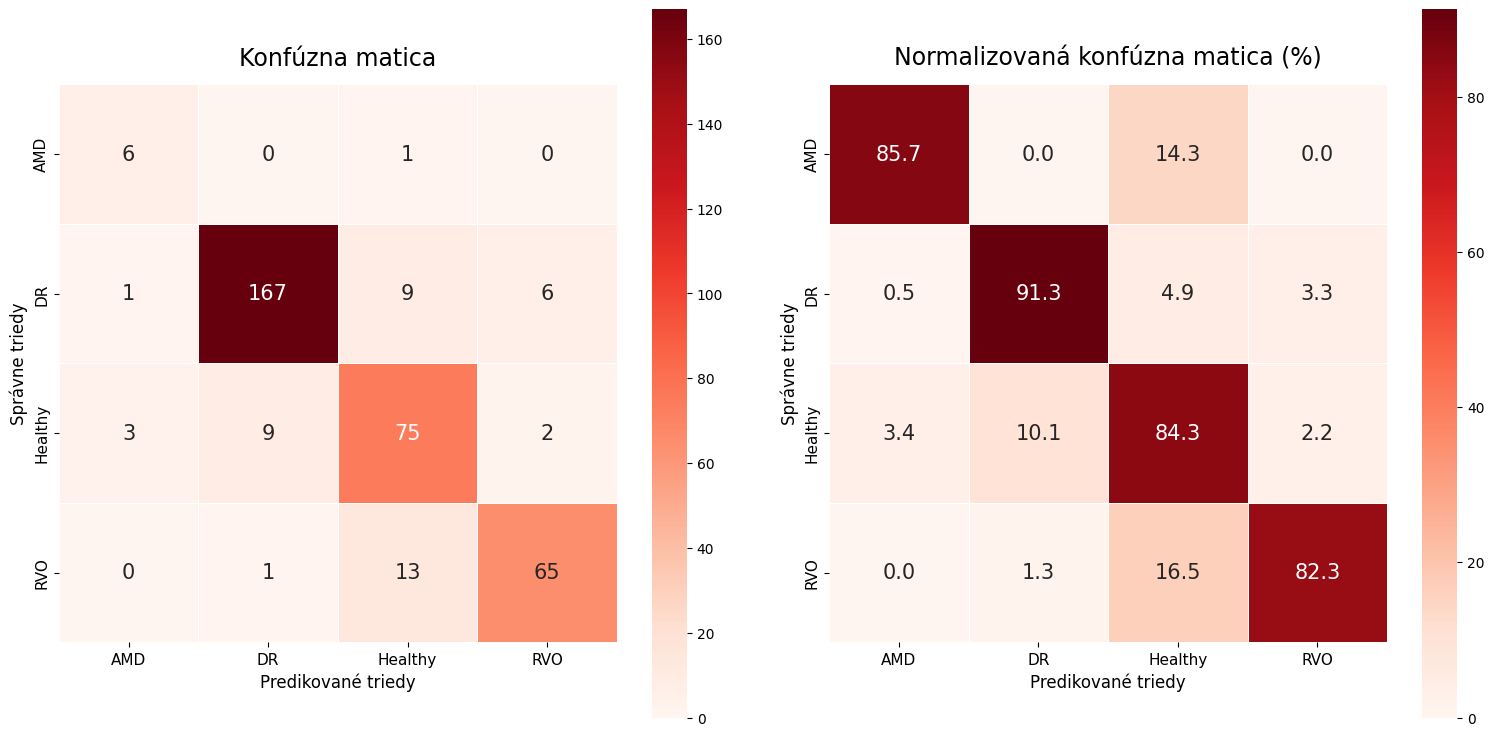

In [8]:
plot_confusion_matrices(
    eval_res    = test_res,
    label_names = LABEL_NAMES,
    save_dir    = BEST_MODEL_DIR,
    show        = True,
)

2026-05-14 11:10:57,278 [INFO] GradCAM uložený → C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model\gradcam\10241_t-AMD_p-AMD.png


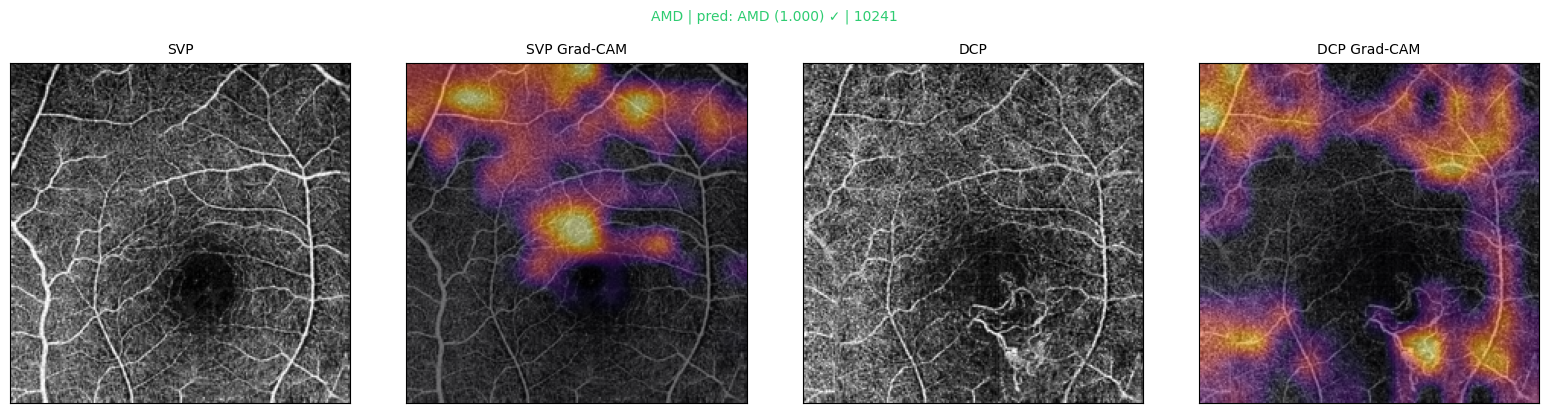

  [1/4] 10241 | true=AMD | pred=AMD (1.000) | ✓


2026-05-14 11:10:57,933 [INFO] GradCAM uložený → C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model\gradcam\10300_t-DR_p-DR.png


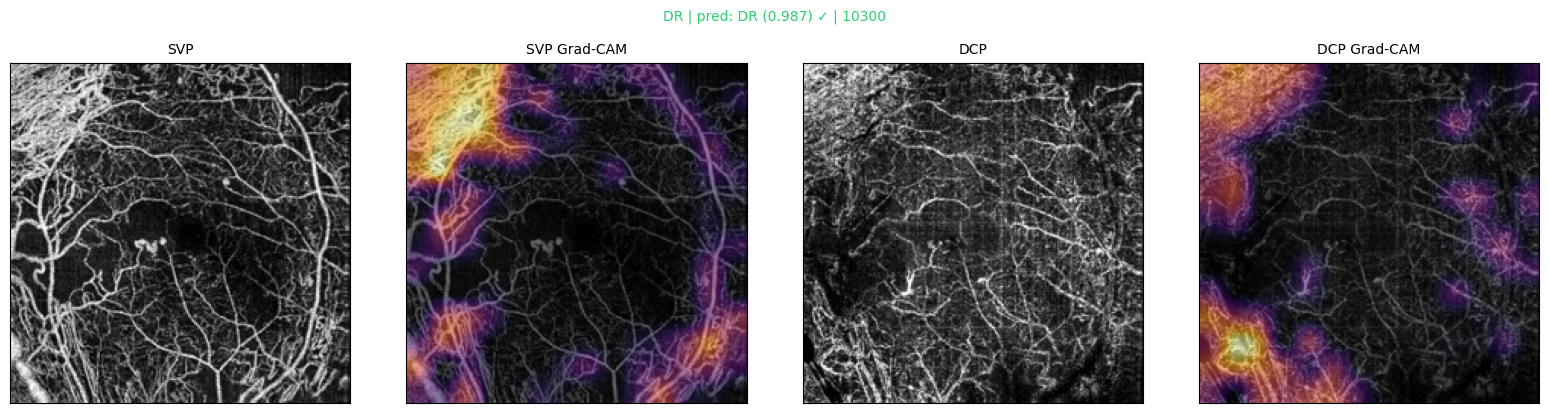

  [2/4] 10300 | true=DR | pred=DR (0.987) | ✓


2026-05-14 11:10:58,496 [INFO] GradCAM uložený → C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model\gradcam\rvo_001_t-RVO_p-RVO.png


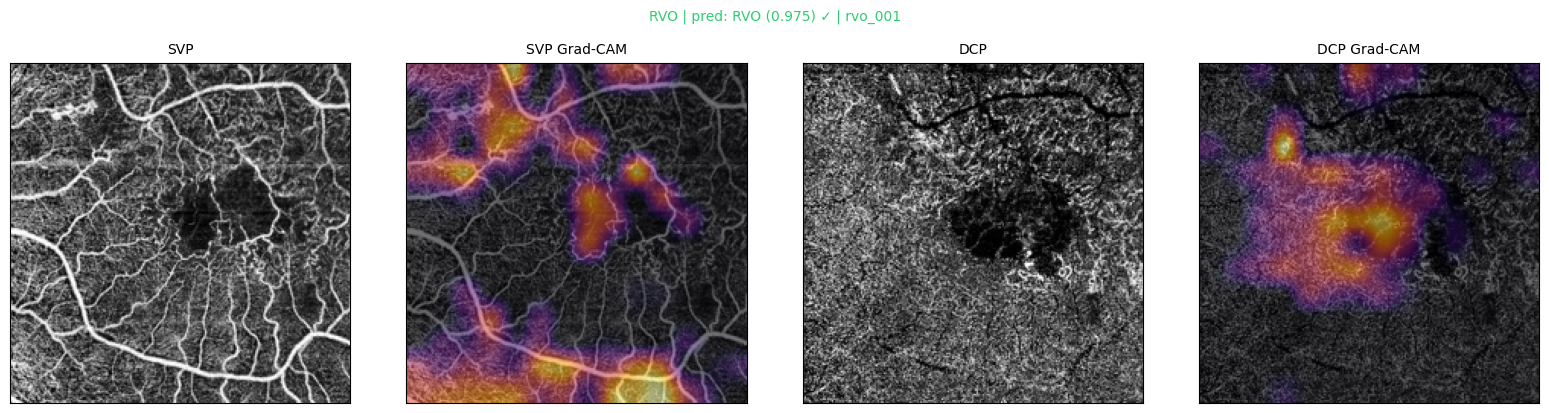

  [3/4] rvo_001 | true=RVO | pred=RVO (0.975) | ✓


2026-05-14 11:10:59,087 [INFO] GradCAM uložený → C:\Users\klara\Desktop\Fianl\03_Model_Training\classifier\results\best_model\gradcam\healthy_001_t-Healthy_p-Healthy.png


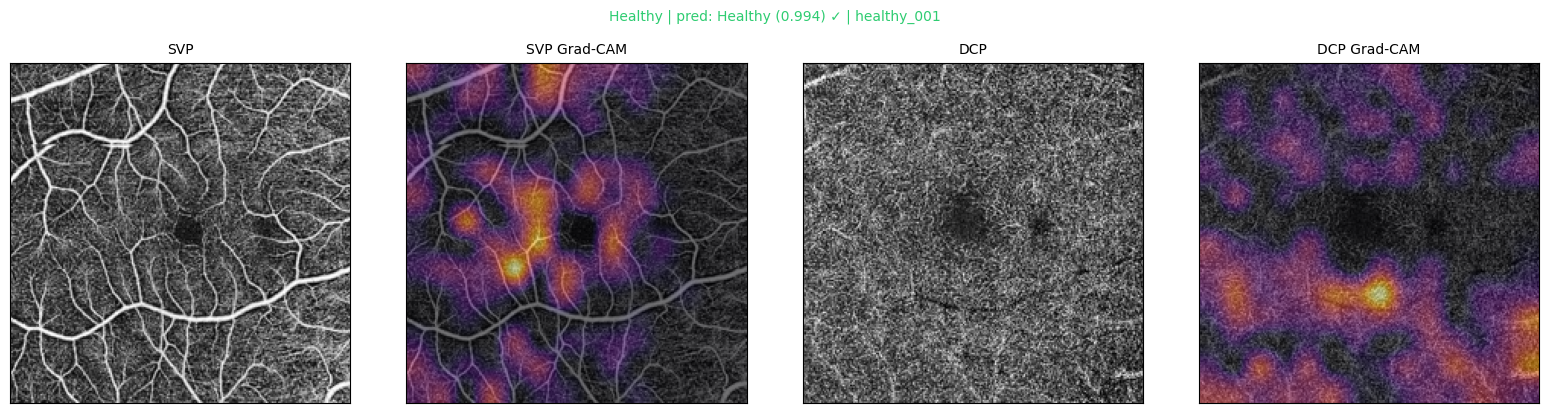

  [4/4] healthy_001 | true=Healthy | pred=Healthy (0.994) | ✓


In [9]:

from scripts.gradcam import run_gradcam

IMAGE_LIST = [
    {
        "svp_path"  : "data/data/10241_superf.png",
        "dcp_path"  : "data/data/10241_prof.png",
        "has_dcp"   : 1,
        "label"     : "AMD",
        "sample_id" : "10241",
    },
    {
        "svp_path"  : "data/data/10300_superf.png",
        "dcp_path"  : "data/data/10300_prof.png",
        "has_dcp"   : 1,
        "label"     : "DR",
        "sample_id" : "10300",
    },
    {
        "svp_path"  : "data/data/surface_20230419102917_Left.png",
        "dcp_path"  : "data/data/deep_20230419102917_Left.png",
        "has_dcp"   : 1,
        "label"     : "RVO",
        "sample_id" : "rvo_001",
    },
    {
        "svp_path"  : "data/data/surface_20230727163420_Right.png",
        "dcp_path"  : "data/data/deep_20230727163420_Right.png",
        "has_dcp"   : 1,
        "label"     : "Healthy",
        "sample_id" : "healthy_001",
    },
]
run_gradcam(
    model        = model,
    encoder_path = ENCODER_PATH,
    image_list   = IMAGE_LIST,
    data_root    = PROJECT_ROOT.parent,   
    save_dir     = BEST_MODEL_DIR / "gradcam",
    device       = device,
    show         = True,
)